<a href="https://colab.research.google.com/github/hyperdbio/Android-inject/blob/master/ex07_%EC%A0%84%EC%9D%B4%ED%95%99%EC%8A%B5_%EA%B0%9C%2C%EA%B3%A0%EC%96%91%EC%9D%B4_%EC%9D%B4%EC%A7%84%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# gpu
# 드라이브 연동
%cd '/content/drive/MyDrive/딥러닝'

/content/drive/MyDrive/딥러닝


## 목표
### 전이학습(Transfer Learning)
- 1. 특성추출방식: 별도 학습x 기존에 쌓여있는 모델을 통해서 데이터를 예측하여 데이터의 중요한 특성만 추출하는 전처리 기술로 활용하는 방식
- 2. 미세조정방식: 특성추출부의 마지막단 학습이 가능하게 하여, 커스텀 데이터셋을 학습시키고 예측에 활용하는 방식

### 전이학습 개념
- 다른 사람이 만들어 놓은 모델을 사용해보자! > 학습 빠르게 수행 가능, 이미 학습된 데이터에 대해 특징을 효율적으로 추출하는 모델을 사용할 수 있다 > 학습할 데이터에 대해 특징 추출하는 학습시간이 필요가 없게 됨(시간 단축)
- 작은 데이터셋에 대해 학습할 때 과대적합 예방 가능
> 미세조정을 하게 되면 학습할 가중치가 줄어 과하게 학습이 진행되지 않음
- 완전 똑같은 데이터로 학습한 것은 아니지만, 비슷한 분류 문제를 푼 모델을 가져와서 사용하는 것
  - 현재 우리 목표 : 개 vs 고양이
  - 사전학습 모델 목표: 사자 vs 호랑이 vs 캥거루 등...(다중분류)
  - 분류하려는 대상은 다르지만, 개수도 다르지만, 동물에 대한 특징을 파악하는 것은 기준이 비슷하기에 가져와서 활용하게 됨
  



In [ ]:
# 사전학습 모델 불러오기
# 사전학습 모델 1개? X, 여러개 0
# VGG16
from tensorflow.keras.applications import VGG16
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# npz
# 증식x, 작은 데이터셋으로도 충분히 성능이 잘 나올 수 있는 기법>> 전이학습
data = np.load('/content/drive/MyDrive/딥러닝/cats_and_dogs_npz')

X_train, y_train, X_test, y_test = data['X_train'], data['y_train'], data['X_test'], data['y_test']

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(2000, 224, 224, 3) (2000,)
(1000, 224, 224, 3) (1000,)


In [ ]:
# 모델 정의
# 특성 추출부만 가져오기
# top : 분류부
vgg16 = VGG16(include_top=False, weights='imagenet', input_shape=(224,224,3))
vgg16

# weights: 기존에 모델이 학습에 사용한 가중치를 가지고 오는 매개변수
# input_shape: 커스텀할 데이터셋의 크기를 지정하는 매개변수

# tensorflow 사이트(문서)에 접근해서 다양한 사전학습 모델을 확인할 수 있음!

<Functional name=vgg16, built=True>

In [ ]:
vgg16.summary()

# input_shape : (224,224,3)
# -- 기존에 모델이 사용한 데이터셋 크기와 현재 커스텀 데이터셋(개,고양이) 크기 동일

# 특성 추출분의 끝 단만 학습이 가능하도록 설정 -> 분류부로 데이터를 넘겨서 예측
# -- 미세조정
# -- 끝단만 학습하는 이유: 전이학습 진행은 사전학습 모델의 w,b를 그대로 연결해서 사용한다.
# 전이학습 진행은 사전학습 모델의 w,b를 그대로 연결해서 사용하는 개념
# 미세조정을 진행하면서 모든 conv층의 학습이 가능하도록 한다면,
# 기존의 잘 학습되어 만들어진 w,b를 모두 훼손하는 개념
# 그래서, 현재 커스텀 데이터셋에 대해서 조금은 인식시키되,
# 전이학습의 의미를 살리기 위해서 끝 단쪽만 학습이 가능하도록 하는 것
# 끝 단쪽의 (끝의 conv층의) w,b를 갱신시킨다라는 의미


# 특성 추출부 가져와서 사용해서 -> 분류부로 데이터를 넘겨서 이진 분류 예측
# -- 전이학습 (특성 추출 방식)

# 학습??? 역전파
# -- 오차값이 크면 모델의 앞으로 전달하면서 최적의 w,b를 찾아나가는 과정 (학습)

# 예측??? 순전파
# -- 데이터 -> 모델 -> 예측값


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 특성추출부를 가져온 상황!
# 동결- w,b가 변동되지 않도록 학습이 불가능하게 모든 층을 고정
vgg16.trainable = False

# 현재상태: 모든 층을 동결
# 특정 층의 이름을 부르면서 trainalbe=True 라고 설정하면, 동결이 풀림


In [ ]:
# 1. 전이학습 - 특성 추출부 + 분류부 : 모델 성능 확인
# 2. 전이학습(미세조정) - 특성 추출부(끝 conv 학습) + 분류부 : 모델 성능 확인
# 1 vs 2

# 모델 설계
transfer_model = Sequential()

# --- 특성 추출부 ----
transfer_model.add(vgg16)
# transfer_model.summary()
# vgg16.summary() : vgg16 기능(함수) 특성추출하는 기능 확인하는 방법


# ---- 분류부 ----
# mlp(이진분류 : 클래스2)
transfer_model.add(Flatten())
# 64
transfer_model.add(Dense(64, activation='relu'))
# 출력층
transfer_model.add(Dense(1, activation='sigmoid'))


# 정보 요약
transfer_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,320,449 (62.26 MB)

 Trainable params: 1,605,761 (6.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# 기존의 cnn_model2 보다 전이학습 진행시 총 파라미터가 훨씬 적음
# 데이터를 이해하는 모델이 꽤나 단순해진 것
#   Total params: 모델의 복잡도를 확인할 수 있는 개념

In [ ]:
# 미세조정 설정
# 마지막 컨볼루션층만 학습가능하도록 설정
# 개, 고양이 이미지에 대한 학습이 가능함
# 마지막 컨볼루션층 이름 확인: block5_conv3
for layer in vgg16.layers:
  if layer.name == 'block5_conv3':
      layer.trainable=True # 학습 가능
  else:
      layer.trainable=False # 동결

In [ ]:
# 컴파일
transfer_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 학습
h2 = transfer_model.fit(X_train,y_train,
                        validation_split=0.3,
                        epochs=10)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 292ms/step - accuracy: 0.8011 - loss: 6.7098 - val_accuracy: 0.8783 - val_loss: 0.3898
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 236ms/step - accuracy: 0.9882 - loss: 0.0327 - val_accuracy: 0.9333 - val_loss: 0.2173
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - accuracy: 0.9899 - loss: 0.0357 - val_accuracy: 0.9533 - val_loss: 0.1633
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 236ms/step - accuracy: 0.9948 - loss: 0.0082 - val_accuracy: 0.9350 - val_loss: 0.2676
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 232ms/step - accuracy: 0.9993 - loss: 0.0019 - val_accuracy: 0.9100 - val_loss: 0.4204
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 232ms/step - accuracy: 0.9986 - loss: 0.0032 - val_accuracy: 0.9050 - val_loss: 0.5288
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 231ms/step - accuracy: 0.9988 - loss: 0.0010 - val_accuracy: 0.9100 - val_loss: 0.5334
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 231ms/step - accuracy: 1.0000 - loss: 1.7637e-04 - val_

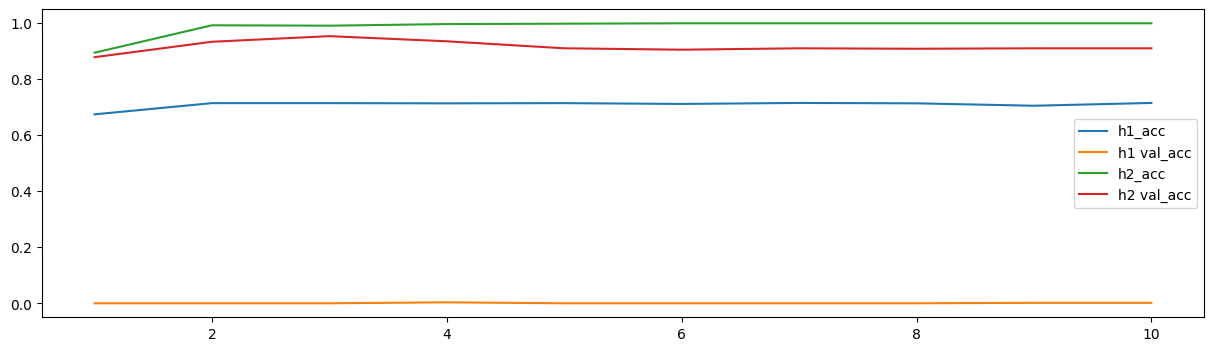

In [ ]:
# h1, acc, val_acc 시각화

plt.figure(figsize=(15,4))


# h1
plt.plot(range(1,len(h1.history['accuracy'])+1),
          h1.history['accuracy'], label='h1_acc')

plt.plot(range(1,len(h1.history['val_accuracy'])+1),
          h1.history['val_accuracy'], label='h1 val_acc')


# h2
plt.plot(range(1,len(h2.history['accuracy'])+1),
          h2.history['accuracy'], label='h2_acc')

plt.plot(range(1,len(h2.history['val_accuracy'])+1),
          h2.history['val_accuracy'], label='h2 val_acc')


plt.legend()
plt.show()

In [ ]:
# 1. 전이학습-특성추출부+분류부(2):
# -- train에 빠르게 학습이 진행되면서, 성능이 100% 가까이 나고 있음
# -- val 에 대해서도 나름대로 학습 우수
# -- train 100% 성능을 조금은 떨어뜨리면서, val에 대한 성능을 조금 더 높일 수 있을까?

# 2. 미세조정: 특성추출부(학습가능) + 분류부(2):
# -- train에 대한 성능은 조금은 떨어질 수 있지만, val 성능은 높일 수 있지 않을까?(기대)
# -- train에 대해 집중하던 내용이 조금은 완화, val 성능도 미세하지만 조금 더 높게
# -- 안정적으로 출력되는 것을 확인함
# -- 1번 방법보다 2번 방법을 수행했을 때, 일반화가 더 진행된 것 같음

# 1 vs 2
# 1번도 성능이 좋았지만, 2번이 조금 더 안정적이라고 판단하면 2번을 사용해서
# 최종 모델을 저장하는 것이 좋겠음

# gpu : 학습을 조금 효과적으로
# cpu : 예측단계에서는 cpu를 활용해도 크게 문제 되지 않음
#       실시간으로 예측의 결과를 연동하는 문제는 gpu를 연결하는게 좋을 수 있음


In [ ]:
# 분류(인식)의 한계?
# -- 이미지 내에 존재하는 다양한 대상에 대한 파악은 어려움
# - YOLO(전이학습): 분류 가능!! > 음식 데이터 > YOLO 모델을 통해 학습 > 이미지 분류

# 탐지를 해보자!
# -- 이미지 내에 다양한 대상을 영역별로 판별하자
# -- 모델: YOLO